# Mimir health -- capture-then-analyze

Collects how Mimir is functioning (series budget, ingest, query load, component health,
ruler/alertmanager, storage, cardinality) into one rendered artifact for humans and agents.
Read-only against the Mimir HTTP API; the raw capture is the authoritative observation,
every analysis cell below it is disposable inference over the capture.

Model: [flight-analysis.ipynb](../../Drones/rekon10/flight-analysis.ipynb) --
design: [tiles#644](https://github.com/symmatree/tiles/issues/644),
[tiles docs/mimir.md](https://github.com/symmatree/tiles/blob/main/docs/mimir.md),
`facts/notebook-analysis/design-intent.md`.

Headless run: `jupyter nbconvert --to notebook --execute --inplace Tiles/Software/mimir-health.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"
tenant = "tiles"       # X-Scope-OrgID for all queries; also the tenant assessed vs limits
lookback_hours = 24
range_step_s = 300
capture_file = ""      # replay a prior raw capture JSON instead of querying live
output_dir = ""        # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import datetime, io, json, time
from pathlib import Path
from IPython.display import display as ipy_display, Image as ipy_image

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

TENANT_COLOR = {}  # fixed color per tenant across all plots, assigned on first sight

def tenant_color(user):
    if user not in TENANT_COLOR:
        TENANT_COLOR[user] = f"C{len(TENANT_COLOR)}"
    return TENANT_COLOR[user]

def show(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    ipy_display(ipy_image(data=buf.getvalue()))

# --- capture layer: every raw API response is recorded under a stable name.
# Analysis reads only through these accessors, so a recorded capture replays identically.
REPLAY = bool(capture_file)
if REPLAY:
    CAPTURE = json.loads(Path(capture_file).read_text())
else:
    CAPTURE = {'meta': {'mimir_url': mimir_url, 'tenant': tenant,
                        'lookback_hours': lookback_hours, 'range_step_s': range_step_s,
                        'now_unix': time.time(),
                        'run_at': datetime.datetime.now(datetime.timezone.utc).isoformat()},
               'calls': {}}
now = CAPTURE['meta']['now_unix']

def call(name, path, **params):
    if REPLAY:
        return CAPTURE['calls'][name]['response']
    r = requests.get(f"{mimir_url}{path}", params=params,
                     headers={'X-Scope-OrgID': tenant}, timeout=60)
    r.raise_for_status()
    resp = r.json()
    CAPTURE['calls'][name] = {'path': path, 'params': params, 'response': resp}
    if debug:
        print(f"  call {name}: {len(r.content)} bytes")
    return resp

def q(name, query):
    return call(name, '/prometheus/api/v1/query', query=query, time=now)['data']['result']

def qr(name, query):
    return call(name, '/prometheus/api/v1/query_range', query=query,
                start=now - lookback_hours * 3600, end=now, step=range_step_s)['data']['result']

def val(res, default=np.nan):
    return float(res[0]['value'][1]) if res else default

def by(res, label):
    return {r['metric'].get(label, ''): float(r['value'][1]) for r in res}

def frame(res, label):
    cols = {}
    for r in res:
        key = r['metric'].get(label, '') if label else 'value'
        cols[key] = pd.Series({pd.to_datetime(t, unit='s', utc=True): float(v)
                               for t, v in r['values']})
    return pd.DataFrame(cols).sort_index()

print(f"mimir: {mimir_url}  tenant: {tenant}  "
      f"{'REPLAY of ' + CAPTURE['meta']['run_at'] if REPLAY else 'live'}")

mimir: http://mimir-gateway.mimir.svc  tenant: tiles  live


In [3]:
# --- ASSUMPTIONS: verify the instruments before trusting any reading ---
# Fatal (whole notebook unassessable): Mimir unreachable, or its self-monitoring
# absent/stale -- the tiles#556 mode where cortex_* is exposed but scraped by nothing,
# so a dead pipeline reads as healthy. Non-fatal: kube_*/cadvisor gaps degrade only
# the component-health section.
assumption_warnings = []
fatal = []

buildinfo = call('buildinfo', '/prometheus/api/v1/status/buildinfo')
mimir_version = buildinfo.get('data', {}).get('version', 'unknown')

STALE_S = 600
freshness = {
    'cortex self-monitoring': 'max(timestamp(cortex_ingester_memory_series))',
    'kube-state-metrics (mimir ns)': 'max(timestamp(kube_pod_info{namespace="mimir"}))',
    'cadvisor (mimir ns)': 'max(timestamp(container_memory_working_set_bytes{namespace="mimir"}))',
}
inst_age = {}
for inst, query in freshness.items():
    ts = val(q(f'fresh: {inst}', query))
    inst_age[inst] = now - ts if not np.isnan(ts) else np.inf

print("=== ASSUMPTIONS ===")
print(f"  mimir {mimir_version} at {mimir_url}: reachable")
for inst, age in inst_age.items():
    status = 'MISSING' if np.isinf(age) else f"newest sample {age:.0f}s old" + (' -- STALE' if age > STALE_S else '')
    print(f"  {inst}: {status}")
    if age > STALE_S:
        msg = f"{inst}: {'absent' if np.isinf(age) else f'stale ({age:.0f}s)'}"
        (fatal if inst.startswith('cortex') else assumption_warnings).append(msg)

if fatal:
    raise RuntimeError("unassessable -- self-monitoring untrustworthy: " + "; ".join(fatal))
for w in assumption_warnings:
    print(f"  WARNING: {w} -- dependent section unassessable")
if not assumption_warnings:
    print("  all ok")

=== ASSUMPTIONS ===
  mimir 3.0.1 at http://mimir-gateway.mimir.svc: reachable
  cortex self-monitoring: newest sample 35s old
  kube-state-metrics (mimir ns): newest sample 53s old
  cadvisor (mimir ns): newest sample 6s old
  all ok


In [4]:
# --- CAPTURE: fetch the complete observation up front, before any analysis,
# so a broken analysis cell cannot cost us the raw snapshot.
series_limit = val(q('series_limit', 'max(cortex_limits_defaults{limit_name="max_global_series_per_user"})'))
active_by_tenant = by(q('active_series_by_tenant', 'sum by (user) (cortex_ingester_active_series)'), 'user')
series_in_memory = val(q('series_in_memory', 'sum(cortex_ingester_memory_series)'))

up_ok = by(q('up_ok_by_job', 'sum by (job) (up{namespace="mimir"})'), 'job')
up_all = by(q('up_targets_by_job', 'count by (job) (up{namespace="mimir"})'), 'job')
restarts = by(q('restarts_by_pod', 'sum by (pod) (kube_pod_container_status_restarts_total{namespace="mimir"})'), 'pod')
last_term = q('last_terminated_reason', 'kube_pod_container_status_last_terminated_reason{namespace="mimir"} == 1')
mem_ws = by(q('mem_working_set_by_pod', 'sum by (pod) (container_memory_working_set_bytes{namespace="mimir", container!=""})'), 'pod')
mem_lim = by(q('mem_limit_by_pod', 'sum by (pod) (kube_pod_container_resource_limits{namespace="mimir", resource="memory"})'), 'pod')

ruler_limits = by(q('ruler_limits', 'cortex_limits_defaults{limit_name=~"ruler_max_.*"}'), 'limit_name')
rule_groups = by(q('rule_groups_by_tenant', 'count by (user) (cortex_prometheus_rule_group_rules)'), 'user')
rules = by(q('rules_by_tenant', 'sum by (user) (cortex_prometheus_rule_group_rules)'), 'user')

compactor_last = val(q('compactor_last_success', 'max(cortex_compactor_last_successful_run_timestamp_seconds)'))
blocks = by(q('blocks_by_tenant', 'max by (user) (cortex_bucket_blocks_count)'), 'user')

f_ingest = frame(qr('ingest_rate', 'sum(rate(cortex_distributor_received_samples_total[5m]))'), None)
f_discard = frame(qr('discarded_by_reason', 'sum by (reason) (rate(cortex_discarded_samples_total[5m]))'), 'reason')
f_active = frame(qr('active_series_trend', 'sum by (user) (cortex_ingester_active_series)'), 'user')
f_qrate = frame(qr('query_rate_by_route', 'sum by (route) (rate(cortex_request_duration_seconds_count{route=~"prometheus_api_v1_.*"}[5m]))'), 'route')
f_qp99 = frame(qr('query_p99', 'histogram_quantile(0.99, sum by (le) (rate(cortex_request_duration_seconds_bucket{route=~"prometheus_api_v1_query.*"}[5m])))'), None)
f_evals = frame(qr('rule_evals', 'sum(rate(cortex_prometheus_rule_evaluations_total[5m]))'), None)
f_evalfail = frame(qr('rule_eval_failures', 'sum(rate(cortex_prometheus_rule_evaluation_failures_total[5m]))'), None)
f_notif = frame(qr('am_notifications_by_integration', 'sum by (integration) (rate(cortex_alertmanager_notifications_total[5m]))'), 'integration')
f_notif_fail = frame(qr('am_notification_failures', 'sum(rate(cortex_alertmanager_notifications_failed_total[5m]))'), None)

card_labels = call('cardinality_label_names', '/prometheus/api/v1/cardinality/label_names', limit=15)
card_metrics = call('cardinality_metric_names', '/prometheus/api/v1/cardinality/label_values',
                    **{'label_names[]': '__name__', 'limit': 15})

print(f"captured {len(CAPTURE['calls'])} calls, ~{len(json.dumps(CAPTURE)) / 1024:.0f} KB raw")

captured 29 calls, ~117 KB raw


per-tenant limit (max_global_series_per_user): 500,000
in-memory series across ingesters: 85,637
       active_series  pct_of_limit
tiles       85,381.0          17.1


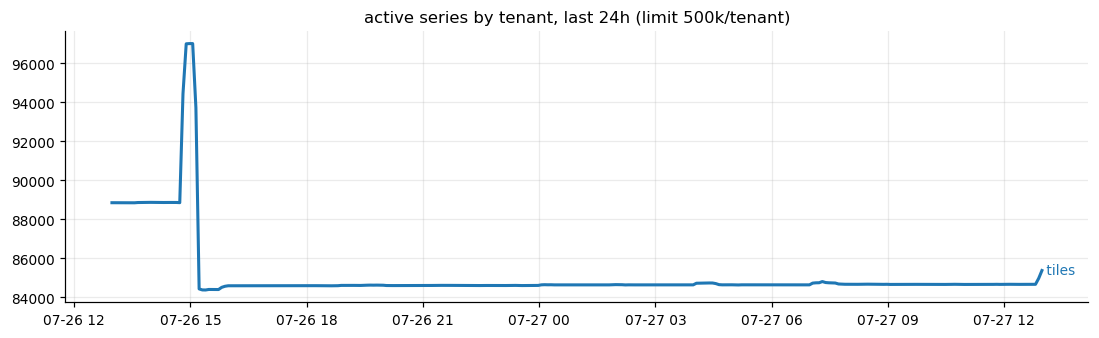

In [5]:
# --- SERIES BUDGET: active series per tenant vs max_global_series_per_user ---
budget = pd.DataFrame({'active_series': pd.Series(active_by_tenant)})
budget['pct_of_limit'] = 100 * budget['active_series'] / series_limit
print(f"per-tenant limit (max_global_series_per_user): {series_limit:,.0f}")
print(f"in-memory series across ingesters: {series_in_memory:,.0f}")
print(budget.sort_values('active_series', ascending=False)
      .to_string(float_format=lambda v: f'{v:,.1f}'))

fig, ax = plt.subplots(figsize=(12, 3.2))
for user in f_active.columns:
    ax.plot(f_active.index, f_active[user], color=tenant_color(user), lw=2)
    ax.annotate(f" {user}", (f_active.index[-1], f_active[user].iloc[-1]),
                color=tenant_color(user), va='center')
ax.set_title(f'active series by tenant, last {lookback_hours}h '
             f'(limit {series_limit / 1e3:.0f}k/tenant)')
show(fig)

ingest: 2,770 samples/s now; mean 2,757, max 2,824 over 24h
discards by reason (mean/s): {'sample-out-of-order': 0.01}


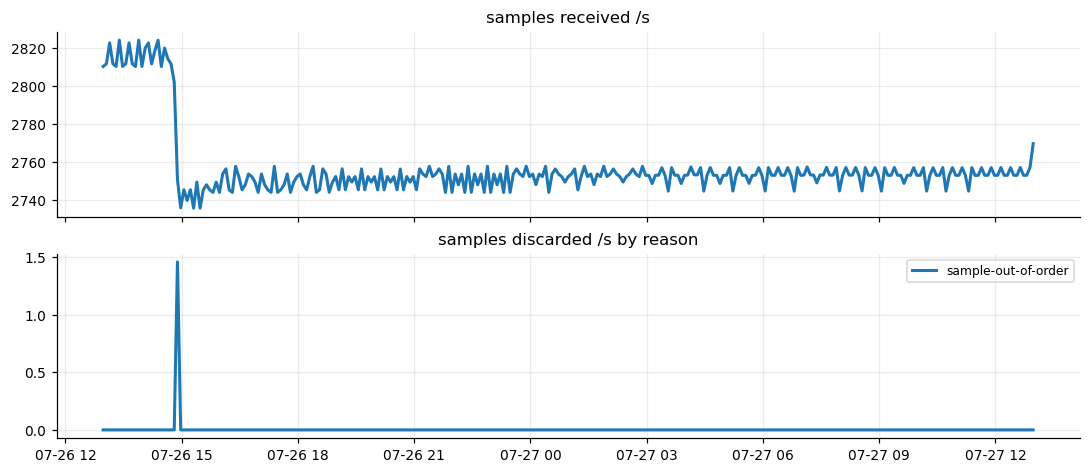

In [6]:
# --- INGEST: samples/s received; discarded/rejected by reason ---
ing = f_ingest['value']
print(f"ingest: {ing.iloc[-1]:,.0f} samples/s now; "
      f"mean {ing.mean():,.0f}, max {ing.max():,.0f} over {lookback_hours}h")
f_discard_nz = f_discard.loc[:, f_discard.max() > 0] if not f_discard.empty else f_discard
discard_now = {c: float(f_discard_nz[c].iloc[-1]) for c in f_discard_nz.columns}
if f_discard_nz.empty:
    print("discards: none in window")
else:
    print(f"discards by reason (mean/s): "
          f"{ {c: round(float(f_discard_nz[c].mean()), 2) for c in f_discard_nz.columns} }")

fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), sharex=True)
axes[0].plot(ing.index, ing, color='C0', lw=2)
axes[0].set_title('samples received /s')
if f_discard_nz.empty:
    axes[1].text(0.5, 0.5, 'no discarded samples in window',
                 ha='center', va='center', transform=axes[1].transAxes, color='0.4')
    axes[1].grid(False)
else:
    for c in f_discard_nz.columns:
        axes[1].plot(f_discard_nz.index, f_discard_nz[c], lw=2, label=c)
    axes[1].legend(fontsize=8)
axes[1].set_title('samples discarded /s by reason')
show(fig)

mean requests/s by route (top 5):
prometheus_api_v1_query                      0.011
prometheus_api_v1_cardinality_label_values   0.009
prometheus_api_v1_query_range                0.006
prometheus_api_v1_cardinality_label_names    0.004
prometheus_api_v1_label_name_values          0.000
query p99 latency: max 0.43s over window


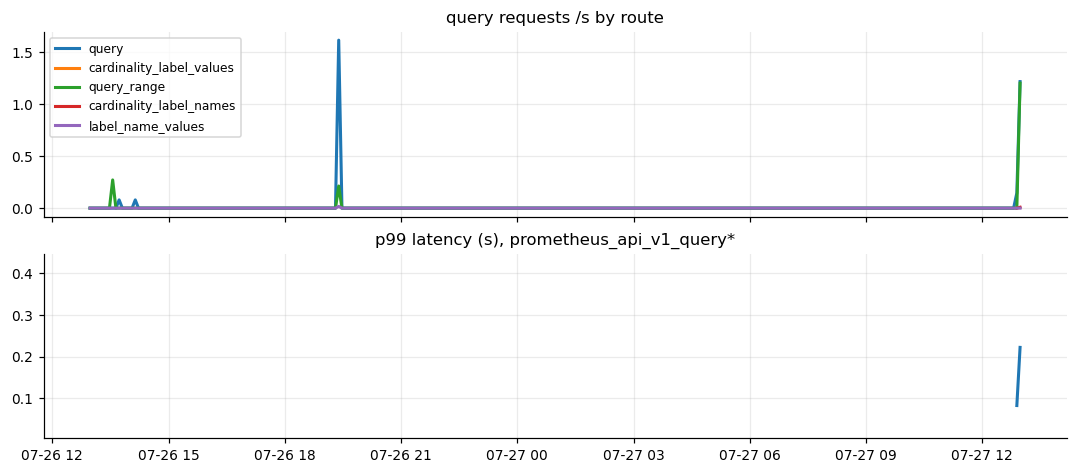

In [7]:
# --- QUERY LOAD: request rate by route; p99 latency for query routes ---
qrate_top = f_qrate.loc[:, f_qrate.mean().sort_values(ascending=False).head(5).index]
print("mean requests/s by route (top 5):")
print(qrate_top.mean().to_string(float_format=lambda v: f'{v:.3f}'))

fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), sharex=True)
for c in qrate_top.columns:
    axes[0].plot(qrate_top.index, qrate_top[c], lw=2,
                 label=c.replace('prometheus_api_v1_', ''))
axes[0].legend(fontsize=8)
axes[0].set_title('query requests /s by route')
p99 = f_qp99['value'] if not f_qp99.empty else pd.Series(dtype=float)
if p99.notna().any():
    axes[1].plot(p99.index, p99, color='C0', lw=2)
    print(f"query p99 latency: max {p99.max():.2f}s over window")
else:
    axes[1].text(0.5, 0.5, 'no query traffic in window', ha='center', va='center',
                 transform=axes[1].transAxes, color='0.4')
    axes[1].grid(False)
axes[1].set_title('p99 latency (s), prometheus_api_v1_query*')
show(fig)

scrape targets DOWN: ['mimir/gateway']
                                           mem_mb  limit_mb  restarts  mem_pct last_term
mimir-kafka-0                                 347         -         0        -         -
mimir-ingester-0                              328         -         9        -     Error
mimir-ingester-1                              298         -         2        -     Error
mimir-store-gateway-0                         218         -         2        -     Error
mimir-ruler-748b9f9c9c-zq4d7                   93         -         0        -         -
mimir-distributor-7ccf8d9fdf-lc5x7             80         -         3        -     Error
mimir-querier-5fffc97669-sktsb                 78         -         3        -     Error
mimir-alertmanager-0                           68       256         0       27         -
mimir-query-frontend-7d69749c4f-bcbxw          50         -         0        -         -
mimir-compactor-0                              45         -         0  

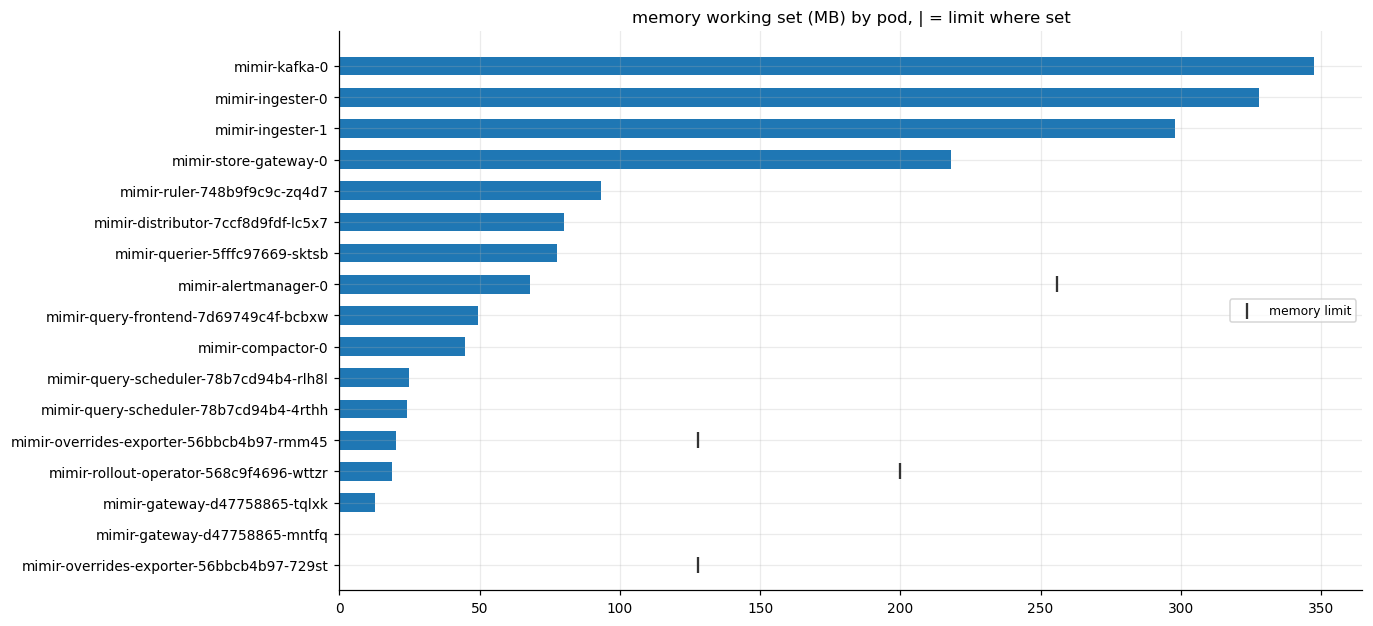

In [8]:
# --- COMPONENT HEALTH: scrape up-ness, restarts, OOMs, memory vs limits ---
scrape = pd.DataFrame({'up': pd.Series(up_ok), 'targets': pd.Series(up_all)})
scrape_down = sorted(scrape[scrape['up'] < scrape['targets']].index)
if scrape_down:
    print(f"scrape targets DOWN: {scrape_down}")
else:
    print(f"all {int(scrape['targets'].sum())} scrape targets up across {len(scrape)} jobs")

pods = pd.DataFrame({'mem_mb': pd.Series(mem_ws) / 2**20,
                     'limit_mb': pd.Series(mem_lim) / 2**20,
                     'restarts': pd.Series(restarts)})
pods['mem_pct'] = 100 * pods['mem_mb'] / pods['limit_mb']
pods['last_term'] = pd.Series({r['metric']['pod']: r['metric']['reason'] for r in last_term})
pods = pods.sort_values('mem_mb', ascending=False)
print(pods.to_string(float_format=lambda v: f'{v:,.0f}', na_rep='-'))

oom_pods = sorted(pods[pods['last_term'] == 'OOMKilled'].index)
restart_pods = {p: int(n) for p, n in pods['restarts'].items() if n > 0}

fig, ax = plt.subplots(figsize=(12, 0.28 * len(pods) + 1))
ax.barh(pods.index[::-1], pods['mem_mb'][::-1], color='C0', height=0.6)
lim = pods['limit_mb'].dropna()
ax.scatter(lim, [list(pods.index[::-1]).index(p) for p in lim.index],
           marker='|', s=120, color='0.2', label='memory limit', zorder=3)
ax.legend(fontsize=8)
ax.set_title('memory working set (MB) by pod, | = limit where set')
show(fig)

ruler per-tenant usage vs limits:
  tiles: 79 groups (limit 200), 447 rules (limit 100/group)
rule evaluations: 7.3/s mean; failures max 0.000/s
alertmanager notifications/s by integration (mean): {'webhook': 0.0042}
alertmanager notification failures: max 0.0046/s


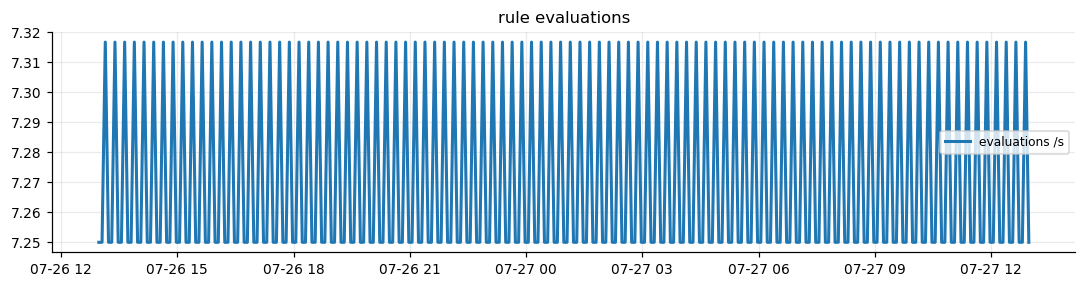

In [9]:
# --- RULER & ALERTMANAGER ---
print("ruler per-tenant usage vs limits:")
for user in sorted(rules):
    print(f"  {user}: {rule_groups.get(user, 0):.0f} groups "
          f"(limit {ruler_limits.get('ruler_max_rule_groups_per_tenant', np.nan):.0f}), "
          f"{rules[user]:.0f} rules "
          f"(limit {ruler_limits.get('ruler_max_rules_per_rule_group', np.nan):.0f}/group)")
evals = f_evals['value'] if not f_evals.empty else pd.Series(dtype=float)
evalfail = f_evalfail['value'] if not f_evalfail.empty else pd.Series(dtype=float)
print(f"rule evaluations: {evals.mean():,.1f}/s mean; "
      f"failures max {evalfail.max() if evalfail.notna().any() else 0:.3f}/s")

notif_mean = {c: round(float(f_notif[c].mean()), 4) for c in f_notif.columns} if not f_notif.empty else {}
nfail = f_notif_fail['value'] if not f_notif_fail.empty else pd.Series(dtype=float)
notif_fail_max = float(nfail.max()) if nfail.notna().any() else 0.0
print(f"alertmanager notifications/s by integration (mean): {notif_mean}")
print(f"alertmanager notification failures: max {notif_fail_max:.4f}/s")

fig, ax = plt.subplots(figsize=(12, 2.6))
ax.plot(evals.index, evals, color='C0', lw=2, label='evaluations /s')
if evalfail.notna().any() and evalfail.max() > 0:
    ax.plot(evalfail.index, evalfail, color='C3', lw=2, label='failures /s')
ax.legend(fontsize=8)
ax.set_title('rule evaluations')
show(fig)

In [10]:
# --- STORAGE: compactor recency, block counts ---
compactor_age_h = (now - compactor_last) / 3600
print(f"compactor last successful run: {compactor_age_h:.1f}h ago")
print(f"blocks by tenant: { {u: int(n) for u, n in sorted(blocks.items())} }")

compactor last successful run: 0.2h ago
blocks by tenant: {'tiles': 181}


tenant 'tiles' series total (cardinality API): 85,746


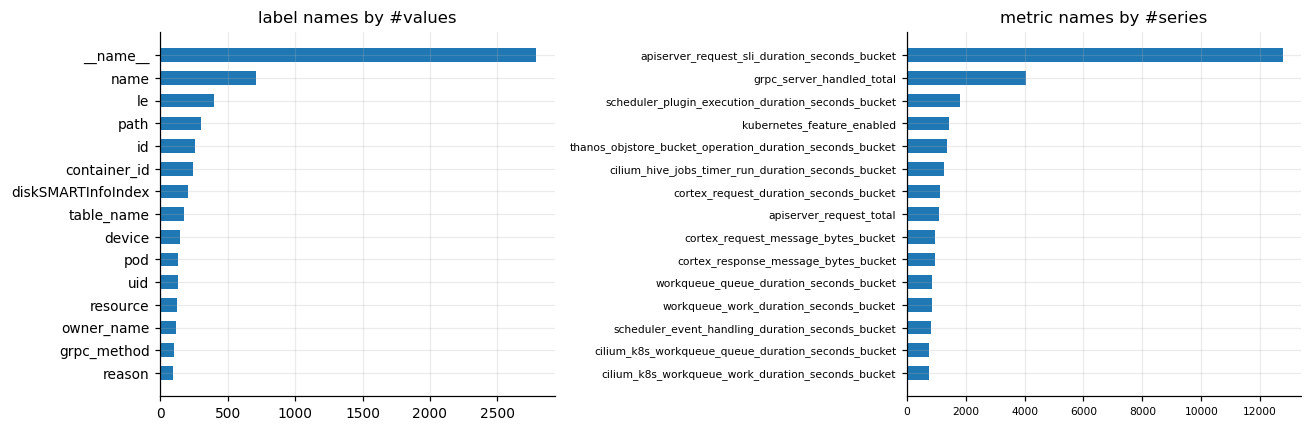

In [11]:
# --- CARDINALITY DRIVERS: what is spending the series budget (tenant view) ---
top_labels = pd.Series({c['label_name']: c['label_values_count']
                        for c in card_labels['cardinality']})
top_metrics = pd.Series({c['label_value']: c['series_count']
                         for c in card_metrics['labels'][0]['cardinality']})
card_total = card_metrics['series_count_total']
print(f"tenant '{tenant}' series total (cardinality API): {card_total:,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(top_labels.index[::-1], top_labels.values[::-1], color='C0', height=0.6)
axes[0].set_title('label names by #values')
axes[1].barh(top_metrics.index[::-1], top_metrics.values[::-1], color='C0', height=0.6)
axes[1].set_title('metric names by #series')
axes[1].tick_params(labelsize=7)
fig.tight_layout()
show(fig)

In [12]:
# --- SUMMARY: assumption ledger first, then findings vs explicit thresholds ---
findings = []
tenant_pct = 100 * active_by_tenant.get(tenant, 0) / series_limit
if tenant_pct > 80:
    findings.append(f"tenant {tenant} at {tenant_pct:.0f}% of series limit (>80%)")
if scrape_down:
    findings.append(f"scrape targets down: {scrape_down}")
if oom_pods:
    findings.append(f"last termination OOMKilled: {oom_pods}")
hot = {p: round(v, 0) for p, v in pods['mem_pct'].dropna().items() if v > 90}
if hot:
    findings.append(f"memory >90% of limit: {hot}")
if not f_discard_nz.empty:
    findings.append(f"samples being discarded: {sorted(f_discard_nz.columns)}")
if evalfail.notna().any() and evalfail.max() > 0:
    findings.append(f"rule evaluation failures present (max {evalfail.max():.3f}/s)")
if notif_fail_max > 0:
    findings.append(f"alertmanager notification failures (max {notif_fail_max:.4f}/s)")
if compactor_age_h > 24:
    findings.append(f"compactor last success {compactor_age_h:.0f}h ago (>24h)")

print("=" * 60)
print("MIMIR HEALTH SUMMARY")
print("=" * 60)
print(f"run:      {CAPTURE['meta']['run_at']}  ({'replay' if REPLAY else 'live'})")
print(f"mimir:    {mimir_version}, tenant {tenant}, lookback {lookback_hours}h")
print()
print("Assumptions: " + ("all instruments fresh" if not assumption_warnings
                         else "; ".join(assumption_warnings)))
print()
if findings:
    print("Findings:")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- all within thresholds")
print()
print(f"  Series:   {active_by_tenant.get(tenant, 0):,.0f} active ({tenant_pct:.0f}% of "
      f"{series_limit / 1e3:.0f}k limit); all tenants: "
      f"{ {u: f'{v:,.0f}' for u, v in sorted(active_by_tenant.items())} }")
print(f"  Ingest:   {ing.mean():,.0f} samples/s mean")
print(f"  Queries:  {qrate_top.mean().sum():.3f} req/s mean across routes")
print(f"  Ruler:    {rules.get(tenant, 0):.0f} rules in {rule_groups.get(tenant, 0):.0f} groups; "
      f"eval failures max {evalfail.max() if evalfail.notna().any() else 0:.3f}/s")
print(f"  Storage:  compactor ok {compactor_age_h:.1f}h ago; "
      f"blocks { {u: int(n) for u, n in sorted(blocks.items())} }")

MIMIR HEALTH SUMMARY
run:      2026-07-27T12:58:30.187113+00:00  (live)
mimir:    3.0.1, tenant tiles, lookback 24h

Assumptions: all instruments fresh

Findings:
  ! scrape targets down: ['mimir/gateway']
  ! samples being discarded: ['sample-out-of-order']
  ! alertmanager notification failures (max 0.0046/s)

  Series:   85,381 active (17% of 500k limit); all tenants: {'tiles': '85,381'}
  Ingest:   2,757 samples/s mean
  Queries:  0.030 req/s mean across routes
  Ruler:    447 rules in 79 groups; eval failures max 0.000/s
  Storage:  compactor ok 0.2h ago; blocks {'tiles': 181}


In [13]:
# AGENT-READABLE STATS -- consolidated JSON; assumption status leads so a reader
# calibrates trust before any verdict.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': 'mimir-health.ipynb',
    'run_at': CAPTURE['meta']['run_at'],
    'mode': 'replay' if REPLAY else 'live',
    'mimir_version': mimir_version,
    'lookback_hours': lookback_hours,
    'assumptions': {
        'status': 'ok' if not assumption_warnings else 'degraded',
        'warnings': assumption_warnings,
        'instrument_age_s': {k: _n(v) for k, v in inst_age.items()},
    },
    'findings': findings,
    'series': {
        'limit_per_tenant': _n(series_limit),
        'active_by_tenant': {u: _n(v) for u, v in active_by_tenant.items()},
        'pct_of_limit_by_tenant': {u: _n(100 * v / series_limit)
                                   for u, v in active_by_tenant.items()},
        'in_memory_total': _n(series_in_memory),
    },
    'ingest': {
        'samples_per_s': {'now': _n(ing.iloc[-1]), 'mean': _n(ing.mean()), 'max': _n(ing.max())},
        'discarded_per_s_now_by_reason': {k: _n(v) for k, v in discard_now.items()},
    },
    'queries': {
        'rate_per_s_mean_by_route': {c: _n(qrate_top[c].mean()) for c in qrate_top.columns},
        'p99_s_max': _n(p99.max()) if p99.notna().any() else None,
    },
    'components': {
        'scrape_down': scrape_down,
        'restarts_by_pod': restart_pods,
        'oom_last_term': oom_pods,
        'mem_pct_of_limit': {p: _n(v) for p, v in pods['mem_pct'].dropna().items()},
    },
    'ruler': {
        'groups_by_tenant': {u: _n(v) for u, v in rule_groups.items()},
        'rules_by_tenant': {u: _n(v) for u, v in rules.items()},
        'limits': {k: _n(v) for k, v in ruler_limits.items()},
        'eval_failures_per_s_max': _n(evalfail.max()) if evalfail.notna().any() else 0,
    },
    'alertmanager': {
        'notifications_per_s_mean_by_integration': notif_mean,
        'failures_per_s_max': _n(notif_fail_max),
    },
    'storage': {
        'compactor_last_success_age_h': _n(compactor_age_h),
        'blocks_by_tenant': {u: int(v) for u, v in blocks.items()},
    },
    'cardinality': {
        'tenant_series_total': int(card_total),
        'top_label_names_by_values': {k: int(v) for k, v in top_labels.items()},
        'top_metrics_by_series': {k: int(v) for k, v in top_metrics.items()},
    },
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    (out / 'mimir-health-capture.json').write_text(json.dumps(CAPTURE))
    (out / 'mimir-health-stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / 'mimir-health-capture.json'} and {out / 'mimir-health-stats.json'}")

{
 "notebook": "mimir-health.ipynb",
 "run_at": "2026-07-27T12:58:30.187113+00:00",
 "mode": "live",
 "mimir_version": "3.0.1",
 "lookback_hours": 24,
 "assumptions": {
  "status": "ok",
  "warnings": [],
  "instrument_age_s": {
   "cortex self-monitoring": 34.5351,
   "kube-state-metrics (mimir ns)": 52.7701,
   "cadvisor (mimir ns)": 6.1711
  }
 },
 "findings": [
  "scrape targets down: ['mimir/gateway']",
  "samples being discarded: ['sample-out-of-order']",
  "alertmanager notification failures (max 0.0046/s)"
 ],
 "series": {
  "limit_per_tenant": 500000.0,
  "active_by_tenant": {
   "tiles": 85381.0
  },
  "pct_of_limit_by_tenant": {
   "tiles": 17.0762
  },
  "in_memory_total": 85637.0
 },
 "ingest": {
  "samples_per_s": {
   "now": 2769.7917,
   "mean": 2756.939,
   "max": 2824.4
  },
  "discarded_per_s_now_by_reason": {
   "sample-out-of-order": 0.0
  }
 },
 "queries": {
  "rate_per_s_mean_by_route": {
   "prometheus_api_v1_query": 0.0108,
   "prometheus_api_v1_cardinality_lab